# Analytical Stability Analysis of the Malaria Transmission Subsystem

## Description
This notebook investigates the analytical stability of the malaria transmission subsystem associated with the reaction matrix of the PDE model. The main objective is to classify the parameter configurations obtained from a systematic scan according to the sign of the spectral abscissa, and then to illustrate representative stable, marginal, and unstable regimes.


## Stability criterion
In the manuscript, the reaction matrix is denoted by \(A_m\). In the code below, the matrix is implemented through the variable `A`, but it corresponds to the same object.

The spectral abscissa is computed as
\[
\rho(A_m) = \max \big\{ \Re(\beta) : \beta \in \sigma(A_m) \big\}.
\]

The stability classification becomes:
\[
\begin{cases}
\rho(A_m) < 0 & \Rightarrow \text{Exponential stability},\\[0.3em]
\rho(A_m) = 0 & \Rightarrow \text{Marginal stability},\\[0.3em]
\rho(A_m) > 0 & \Rightarrow \text{Instability}.
\end{cases}
\]

## Scope of the notebook
The notebook is organized into five main steps:

1. **Global parameter sweep and stability classification** based on the spectral abscissa.
2. **Identification of stable parameter ranges** over the scanned domain.
3. **Interactive exploration of specific parameter combinations** to inspect individual regimes.
4. **Search for epidemiologically plausible stable configurations** under a prevalence constraint.
5. **Generation of publication-oriented figures** summarizing the stability landscape.

The numerical results displayed in the outputs below are those produced by the original notebook and are kept consistent with that implementation.


## 1. Global parameter sweep and stability classification

This section performs a systematic scan over the selected parameter ranges. For each triplet \((\Lambda,\phi,f_T)\), the code builds the reaction matrix and evaluates its eigenstructure. The primary criterion is the spectral abscissa, while the symmetric part is used only as a complementary diagnostic quantity.

The resulting classes are:
- **Stable** when the spectral abscissa is negative,
- **Marginal** when it is zero up to the numerical tolerance used in the code,
- **Instable** when it is positive.

The output reports the class counts over the scanned grid and lists representative stability intervals.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import math
import csv
from collections import defaultdict

# ---------------------------
# 0. Fixed parameters & A_m generation
# ---------------------------
params_fixed = {
    "Lambda": 0.35, "phi": 0.4, "f_T": 0.5,
    "d_D": 5, "d_T": 5.0, "d_A": 25.0, "d_P": 110.0
}

def get_A_m(p):
    Λ, φ, fT = p["Lambda"], p["phi"], p["f_T"]
    d_D, d_T, d_A, d_P = p["d_D"], p["d_T"], p["d_A"], p["d_P"]
    return np.array([
        [-Λ,              0,     0,        1/d_A,     1/d_P],
        [φ*(1-fT)*Λ,   -1/d_D,   0,     φ*(1-fT)*Λ,     0   ],
        [φ*fT*Λ,          0,   -1/d_T,  φ*fT*Λ,         0   ],
        [(1-φ)*Λ,       1/d_D,   0,  -(φ*Λ + 1/d_A),    0   ],
        [0,               0,    1/d_T,      0,        -1/d_P]
    ], dtype=float)

# ---------------------------
# 1. Classification (rho(A_m) primary, As diagnostic)
# ---------------------------
def classify_stability(A_m, tol=0):
    eigvals = np.linalg.eigvals(A_m)
    rho = np.max(np.real(eigvals))            # spectral abscissa
    As = 0.5 * (A_m + A_m.T)
    beta_max_As = np.max(np.real(np.linalg.eigvals(As)))
    if rho < -tol:
        cls = "Stable"      # exponential stability
    elif abs(rho) <= tol:
        cls = "Marginal"
    else:
        cls = "Unstable"
    return cls, float(rho), float(beta_max_As)

# ---------------------------
# 2. Parametric grid (modifiable)
# ---------------------------
Λ_vals  = np.linspace(0.1, 0.5, 15)   # transmission rate
φ_vals  = np.linspace(0.2, 0.8, 20)   # clinical disease rate
fT_vals = np.linspace(0.1, 0.7, 20)   # treatment rate

# Pre-allocate
NΛ = len(Λ_vals); Nφ = len(φ_vals); Nf = len(fT_vals)
points = []  # list of (Λ, φ, fT, cls, rho, beta_max_As)

for i, Λ in enumerate(Λ_vals):
    for j, φ in enumerate(φ_vals):
        for k, fT in enumerate(fT_vals):
            params = {**params_fixed, "Lambda": Λ, "phi": φ, "f_T": fT}
            A_m = get_A_m(params)
            cls, rho, beta_As = classify_stability(A_m)
            points.append((Λ, φ, fT, cls, rho, beta_As))

# Convert to numpy object array for convenience
results = np.array(points, dtype=object)

# ---------------------------
# 3. Global summary & CSV export
# ---------------------------
# Count classes
from collections import Counter
cnt = Counter(results[:,3])
print("Class counts:", cnt)

# Save to CSV for inspection
csv_fname = "stability_scan_results.csv"
with open(csv_fname, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["Lambda","phi","fT","class","rho(A_m)","beta_max(As)"])
    for row in results:
        writer.writerow(row)
print(f"Results saved to {csv_fname}")

# ---------------------------
# 4. Interactive 3D Plotly scatter with class-based colors
# ---------------------------
Λ_list, φ_list, fT_list, cls_list, rho_list, betaAs_list = zip(*points)

color_map = {"Stable": "green", "Marginal": "blue", "Unstable": "red"}
fig = px.scatter_3d(
    x=Λ_list, y=φ_list, z=fT_list,
    color=cls_list,
    color_discrete_map=color_map,
    labels={"x": "Λ (transmission)", "y": "φ (disease)", "z": "f_T (treatment)"},
    title="Stability analysis (rho(A_m)): parametric space (Λ, φ, f_T)",
    hover_data={"rho(A_m)": rho_list, "beta_max(As)": betaAs_list}
)
fig.update_traces(marker=dict(size=4))
fig.show()


# ---------------------------
# 5. Automatic analysis of stable ranges (global + 1D contiguous intervals by slice)
# ---------------------------
# Global min/max of stable points (simple)
stable_mask = (results[:,3] == "Stable")
if stable_mask.sum() == 0:
    print("No exponentially stable configuration was found on the grid.")
else:
    lambdas_stable = results[stable_mask, 0].astype(float)
    phis_stable = results[stable_mask, 1].astype(float)
    fTs_stable = results[stable_mask, 2].astype(float)
    print("Global stability ranges (overall min/max):")
    print(f"  Λ in [{lambdas_stable.min():.4f}, {lambdas_stable.max():.4f}]")
    print(f"  φ in [{phis_stable.min():.4f}, {phis_stable.max():.4f}]")
    print(f"  f_T in [{fTs_stable.min():.4f}, {fTs_stable.max():.4f}]")

# Function to find contiguous intervals (1D) from boolean array aligned with values
def find_contiguous_intervals(values, bool_mask):
    # values assumed sorted ascending
    intervals = []
    if np.sum(bool_mask) == 0:
        return intervals
    idxs = np.where(bool_mask)[0]
    # group consecutive indices
    group = [idxs[0]]
    for idx in idxs[1:]:
        if idx == group[-1] + 1:
            group.append(idx)
        else:
            intervals.append((values[group[0]], values[group[-1]]))
            group = [idx]
    intervals.append((values[group[0]], values[group[-1]]))
    return intervals

# Example: for each fixed (phi, fT), get Λ-intervals where stability holds (this can be large)
stable_intervals_by_phi_fT = {}
φ_interval = np.linspace(0.7, 0.85, 15)
for j, φ in enumerate(φ_interval):
    for k, fT in enumerate(fT_vals):
        mask = []
        for i, Λ in enumerate(Λ_vals):
            params = {**params_fixed, "Lambda": Λ, "phi": φ, "f_T": fT}
            cls, _, _ = classify_stability(get_A_m(params))
            mask.append(cls == "Stable")
        mask = np.array(mask)
        intervals = find_contiguous_intervals(Λ_vals, mask)
        if intervals:
            stable_intervals_by_phi_fT[(round(φ,4), round(fT,4))] = intervals

# Print a short summary (only first 10 found)
print("\nExamples of stable Λ-intervals for selected (φ, f_T) pairs (max 10):")
for i, ((phi_val, fT_val), intervals) in enumerate(stable_intervals_by_phi_fT.items()):
    if i >= 10: break
    print(f" φ={phi_val}, f_T={fT_val} -> Λ intervals: {intervals}")

# ---------------------------
# 6. Spectral diagnostics for selected cases (examples)
# ---------------------------
def print_spectrum_for(params):
    A_m = get_A_m(params)
    eigs = np.linalg.eigvals(A_m)
    As = 0.5*(A_m + A_m.T)
    eigs_As = np.linalg.eigvals(As)
    print("Parameters:", params)
    print("Real parts of Eigen(A_m):", np.real(eigs))
    print("rho(A_m) =", np.max(np.real(eigs)))
    print("Eigen(As):", np.real(eigs_As))
    print("beta_max(As) =", np.max(np.real(eigs_As)))
    print("-"*50)

# Example diagnostics (center of the domain)
center_params = {**params_fixed, "Lambda": float(Λ_vals[NΛ//2]), "phi": float(φ_vals[Nφ//2]), "f_T": float(fT_vals[Nf//2])}
print_spectrum_for(center_params)

# Another example: extremes
print_spectrum_for({**params_fixed, "Lambda": Λ_vals[-1], "phi": φ_vals[-1], "f_T": fT_vals[-1]})

Class counts: Counter({'Stable': 2886, 'Unstable': 2794, 'Marginal': 320})
Results saved to stability_scan_results.csv


Global stability ranges (overall min/max):
  Λ in [0.1000, 0.5000]
  φ in [0.2000, 0.8000]
  f_T in [0.1000, 0.7000]

Examples of stable Λ-intervals for selected (φ, f_T) pairs (max 10):
 φ=0.7, f_T=0.1 -> Λ intervals: [(np.float64(0.1285714285714286), np.float64(0.1285714285714286)), (np.float64(0.18571428571428572), np.float64(0.2142857142857143)), (np.float64(0.3571428571428572), np.float64(0.3571428571428572)), (np.float64(0.44285714285714284), np.float64(0.44285714285714284))]
 φ=0.7, f_T=0.1316 -> Λ intervals: [(np.float64(0.1), np.float64(0.1285714285714286)), (np.float64(0.18571428571428572), np.float64(0.18571428571428572)), (np.float64(0.30000000000000004), np.float64(0.30000000000000004)), (np.float64(0.3571428571428572), np.float64(0.3857142857142858)), (np.float64(0.4714285714285714), np.float64(0.4714285714285714))]
 φ=0.7, f_T=0.1632 -> Λ intervals: [(np.float64(0.1), np.float64(0.1285714285714286)), (np.float64(0.18571428571428572), np.float64(0.2142857142857143)), (np.

## 2. Interactive inspection of selected parameter combinations

This section tests individual parameter combinations and prints a detailed diagnostic summary. It is useful for discussing representative epidemiological scenarios and for connecting the stability label to the corresponding values of the spectral abscissa and the auxiliary symmetric-matrix indicator.



In [4]:
# ---------------------------
# 7. INTERACTIVE INTERFACE - TESTING SPECIFIC COMBINATIONS
# ---------------------------

def test_stability_combination(Lambda_test, phi_test, fT_test, params_fixed, verbose=True):
    """
    Tests the stability for a specific parameter combination.
    """
    # Create the test parameters
    test_params = {
        "Lambda": Lambda_test,
        "phi": phi_test,
        "f_T": fT_test,
        "d_D": params_fixed["d_D"],
        "d_T": params_fixed["d_T"],
        "d_A": params_fixed["d_A"],
        "d_P": params_fixed["d_P"]
    }

    # Compute the matrix A_m
    A_m = get_A_m(test_params)

    # Stability classification
    cls, rho, beta_max_As = classify_stability(A_m)

    if verbose:
        print("=" * 60)
        print(" STABILITY ANALYSIS - SPECIFIC COMBINATION")
        print("=" * 60)
        print(f"Tested parameters:")
        print(f"  • Λ (infection rate)           = {Lambda_test:.4f}")
        print(f"  • φ (clinical disease probability)     = {phi_test:.4f}")
        print(f"  • f_T (treatment coverage)     = {fT_test:.4f}")
        print(f"  • d_D (disease duration)       = {params_fixed['d_D']} days")
        print(f"  • d_T (treatment duration)     = {params_fixed['d_T']} days")
        print(f"  • d_A (immunity duration)      = {params_fixed['d_A']} days")
        print(f"  • d_P (protection duration)    = {params_fixed['d_P']} days")
        print("\n" + "─" * 40)
        print(" STABILITY RESULTS:")
        print(f"  • Spectral abscissa ρ(A_m)     = {rho:.6f}")
        print(f"  • Stability class              = {cls}")

        # Detailed diagnostic
        if cls == "Stable":
            print(f"   STABLE SYSTEM - Exponential convergence")
        elif cls == "Marginal":
            print(f"    MARGINAL SYSTEM - Neutral stability")
        else:
            print(f"   UNSTABLE SYSTEM - Exponential divergence")

        print(f"  • β_max(A_symmetric)           = {beta_max_As:.6f}")

        print("=" * 60)

    return {
        "class": cls,
        "rho": rho,
        "beta_max_As": beta_max_As,
        "params": test_params
    }

# ---------------------------
# 8. EXAMPLES OF INTERFACE USAGE
# ---------------------------


print("INTERACTIVE INTERFACE FOR STABILITY TESTING")


# Example 1: Realistic combination for Burkina Faso
print("\n1. REALISTIC COMBINATION (Burkina Faso context):")
result1 = test_stability_combination(
    Lambda_test=0.35,    # Realistic rate
    phi_test=0.4,        # 40% clinical cases
    fT_test=0.5,         # 50% treatment coverage
    params_fixed=params_fixed
)

# Example 2: Unstable combination
print("\n2. UNSTABLE COMBINATION (high transmission):")
result2 = test_stability_combination(
    Lambda_test=0.3,     # High transmission
    phi_test=0.7,        # Many clinical cases
    fT_test=0.1,         # Low treatment
    params_fixed=params_fixed
)

# Example 3: Marginal combination
print("\n3. MARGINAL COMBINATION (critical situation):")
result3 = test_stability_combination(
    Lambda_test=0.15,    # Moderate transmission
    phi_test=0.5,        # 50% clinical cases
    fT_test=0.2,         # Limited treatment
    params_fixed=params_fixed
)

# ---------------------------
# 9. FUNCTION FOR INTERACTIVE TESTING
# ---------------------------

def interface_interactive_test():
    """
    Interface to test your own parameter combinations.
    """

    print("INTERACTIVE TEST - ENTER YOUR PARAMETERS")


    try:
        # Parameter input
        Lambda_user = float(input("Enter Λ (infection rate, e.g. 0.01): "))
        phi_user = float(input("Enter φ (clinical disease probability, e.g. 0.4): "))
        fT_user = float(input("Enter f_T (treatment coverage, e.g. 0.3): "))

        # Stability test
        result = test_stability_combination(
            Lambda_test=Lambda_user,
            phi_test=phi_user,
            fT_test=fT_user,
            params_fixed=params_fixed
        )

        # Save result
        print(f"\n Result saved. Class: {result['class']}")

        return result

    except ValueError:
        print(" Error: Please enter valid numeric values")
        return None


# ---------------------------
# 11. LAUNCH THE INTERACTIVE INTERFACE (UNCOMMENT TO USE)
# ---------------------------

# Uncomment the following line to test the interactive interface
# result_user = interface_interactive_test()


# ---------------------------
# END WITH COMPLETE INTERFACE
# ---------------------------

print("COMPLETE PIPELINE FINISHED")

print("\nAvailable functions:")
print("• test_stability_combination() - Unit test")
print("• interface_interactive_test() - Interactive interface")

INTERACTIVE INTERFACE FOR STABILITY TESTING

1. REALISTIC COMBINATION (Burkina Faso context):
 STABILITY ANALYSIS - SPECIFIC COMBINATION
Tested parameters:
  • Λ (infection rate)           = 0.3500
  • φ (clinical disease probability)     = 0.4000
  • f_T (treatment coverage)     = 0.5000
  • d_D (disease duration)       = 5 days
  • d_T (treatment duration)     = 5.0 days
  • d_A (immunity duration)      = 25.0 days
  • d_P (protection duration)    = 110.0 days

────────────────────────────────────────
 STABILITY RESULTS:
  • Spectral abscissa ρ(A_m)     = -0.000000
  • Stability class              = Stable
   STABLE SYSTEM - Exponential convergence
  • β_max(A_symmetric)           = 0.039758

2. UNSTABLE COMBINATION (high transmission):
 STABILITY ANALYSIS - SPECIFIC COMBINATION
Tested parameters:
  • Λ (infection rate)           = 0.3000
  • φ (clinical disease probability)     = 0.7000
  • f_T (treatment coverage)     = 0.1000
  • d_D (disease duration)       = 5 days
  • d_T (trea

## 3. Manual interactive test

This cell runs the interactive routine and evaluates a user-provided triplet \((\Lambda,\phi,f_T)\). The stored output below corresponds to the values originally entered in the notebook session.


In [5]:
interface_interactive_test()

INTERACTIVE TEST - ENTER YOUR PARAMETERS
Enter Λ (infection rate, e.g. 0.01): 0.5
Enter φ (clinical disease probability, e.g. 0.4): 0.1
Enter f_T (treatment coverage, e.g. 0.3): 0.9
 STABILITY ANALYSIS - SPECIFIC COMBINATION
Tested parameters:
  • Λ (infection rate)           = 0.5000
  • φ (clinical disease probability)     = 0.1000
  • f_T (treatment coverage)     = 0.9000
  • d_D (disease duration)       = 5 days
  • d_T (treatment duration)     = 5.0 days
  • d_A (immunity duration)      = 25.0 days
  • d_P (protection duration)    = 110.0 days

────────────────────────────────────────
 STABILITY RESULTS:
  • Spectral abscissa ρ(A_m)     = 0.000000
  • Stability class              = Unstable
   UNSTABLE SYSTEM - Exponential divergence
  • β_max(A_symmetric)           = 0.065821

 Result saved. Class: Unstable


{'class': 'Unstable',
 'rho': 2.449579578790034e-18,
 'beta_max_As': 0.06582083231775042,
 'params': {'Lambda': 0.5,
  'phi': 0.1,
  'f_T': 0.9,
  'd_D': 5,
  'd_T': 5.0,
  'd_A': 25.0,
  'd_P': 110.0}}

## 5. Publication-oriented figures

This final section generates the figures used to summarize the stability analysis. These graphics illustrate phase-diagram views, heatmaps, distributions of spectral abscissae, and threshold-type summaries over the explored parameter space.


CREATING FIGURES FOR THE ARTICLE
CREATING FIGURES FOR THE ARTICLE


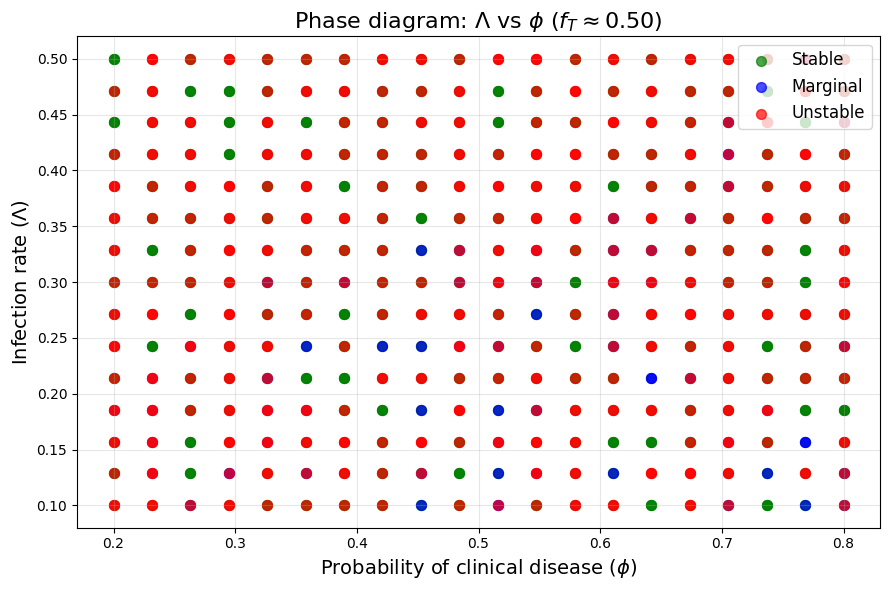

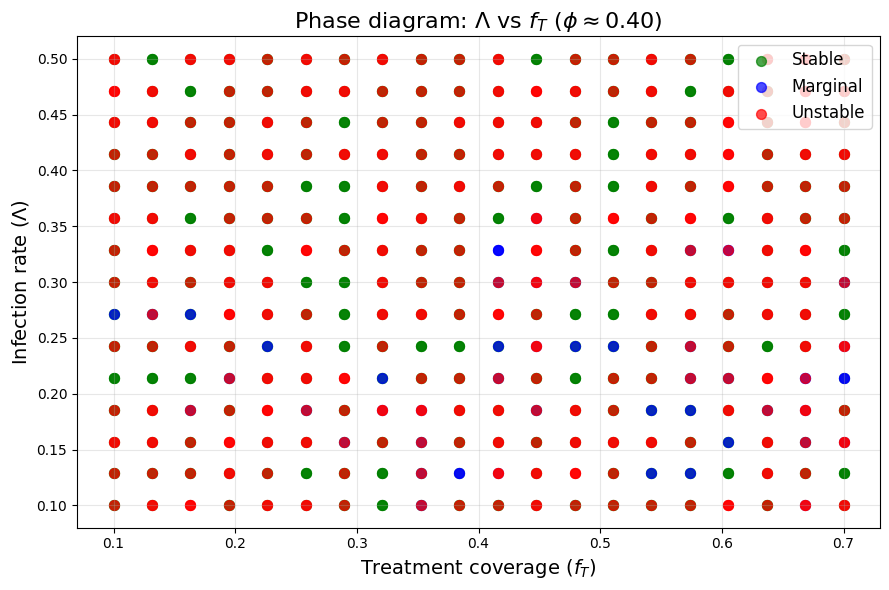

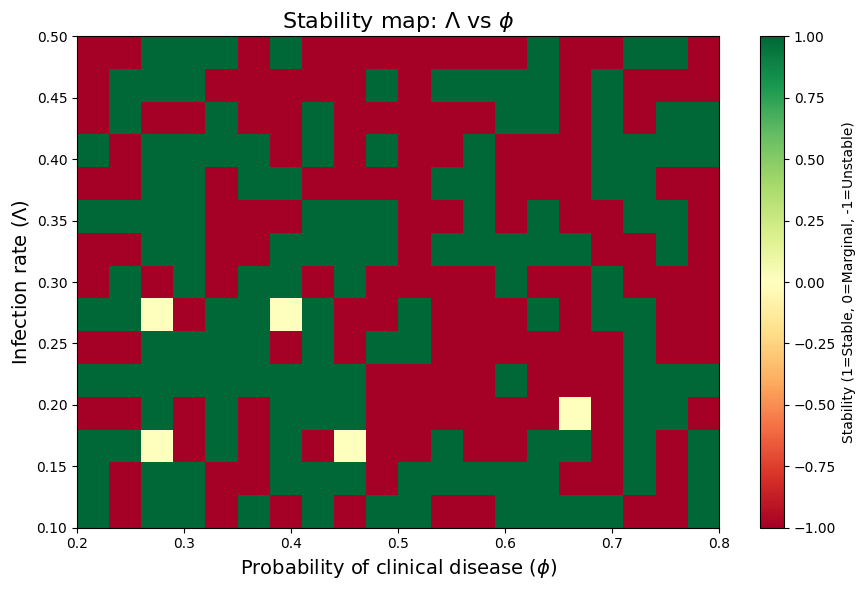

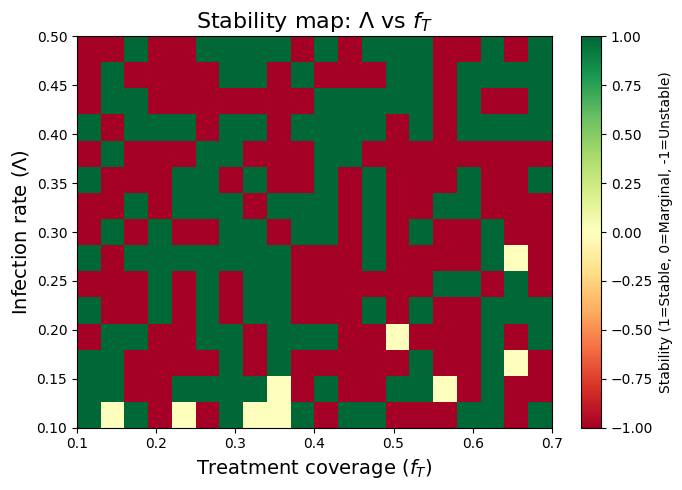

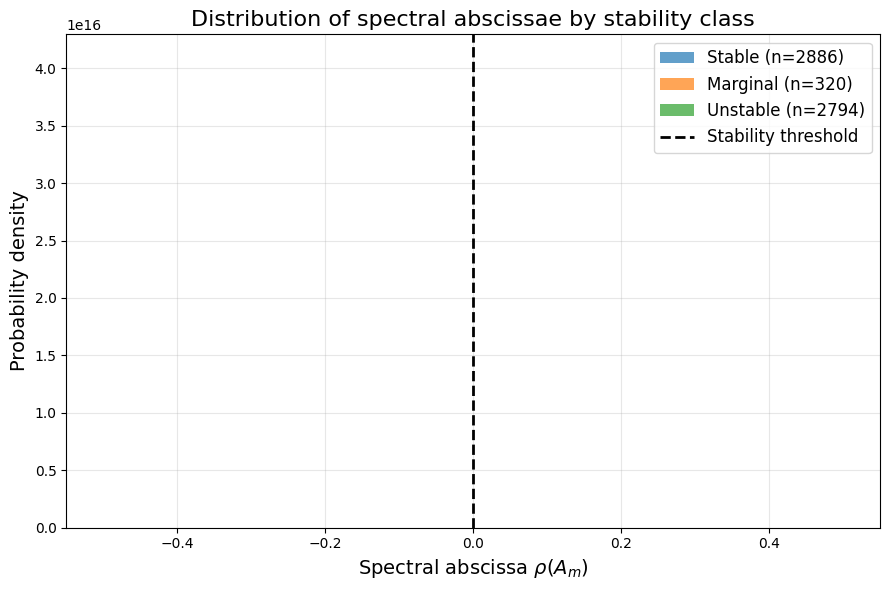

Ternary diagram displayed (not exported).

 ALL FIGURES HAVE BEEN CREATED AND SAVED (except the ternary diagram).
CRITICAL THRESHOLD FIGURES


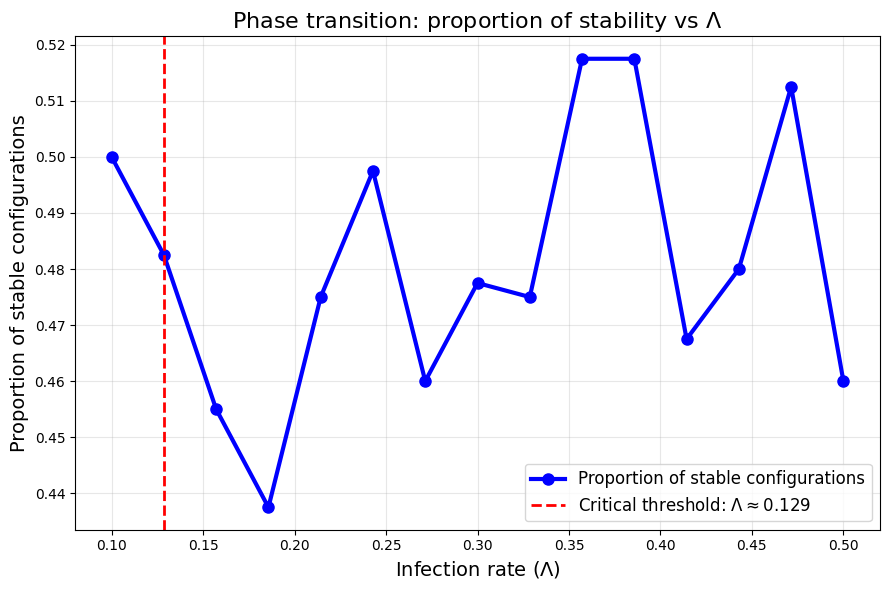

Identified critical threshold: Λ ≈ 0.129


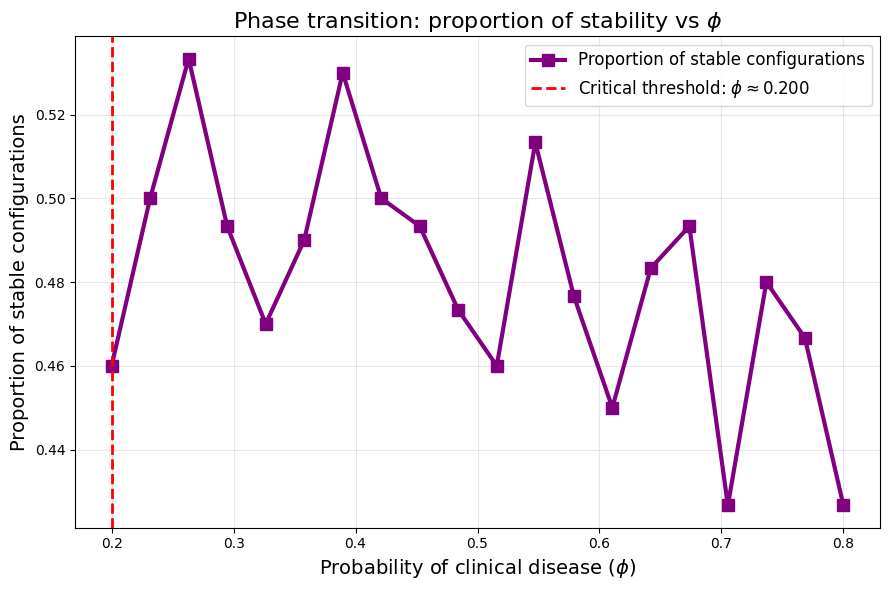

 Identified critical threshold: φ ≈ 0.200
FIGURES COMPLETED - READY FOR THE ARTICLE

 Generated files (PDF):
• phase_diagram_lambda_phi.pdf
• phase_diagram_lambda_fT.pdf
• stability_heatmap_lambda_phi.pdf
• spectral_abscissa_distribution.pdf
• critical_threshold_lambda.pdf
• critical_threshold_phi.pdf
• Ternary diagram displayed but not exported


In [6]:
# ---------------------------
# 12. 2D FIGURES FOR THE SCIENTIFIC ARTICLE
# ---------------------------

def creer_graphiques_article(results, params_fixed):
    """
    Creates professional 2D figures for the article -
    """

    print("CREATING FIGURES FOR THE ARTICLE")

    # Extract data
    lambdas = results[:, 0].astype(float)
    phis = results[:, 1].astype(float)
    fTs = results[:, 2].astype(float)
    classes = results[:, 3]
    rhos = results[:, 4].astype(float)

    # Colors for the classes
    colors = {'Stable': 'green', 'Marginal': 'blue', 'Unstable': 'red'}

    # ---------------------------------------------------------------------
    # FIGURE 1: Phase diagram (Λ vs φ) with fixed f_T
    # ---------------------------------------------------------------------
    plt.figure(figsize=(9, 6))

    fT_median = 0.5
    fT_tolerance = 0.05
    mask_fT = (np.abs(fTs - fT_median) < fT_tolerance)

    for cls in ['Stable', 'Marginal', 'Unstable']:
        mask_cls = (classes == cls) & mask_fT
        if np.sum(mask_cls) > 0:
            plt.scatter(phis[mask_cls], lambdas[mask_cls],
                       c=colors[cls], label=cls, s=50, alpha=0.7)

    plt.xlabel('Probability of clinical disease ($\\phi$)', fontsize=14)
    plt.ylabel('Infection rate ($\\Lambda$)', fontsize=14)
    plt.title(f'Phase diagram: $\\Lambda$ vs $\\phi$ ($f_T \\approx {fT_median:.2f}$)', fontsize=16)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    # plt.savefig('phase_diagram_lambda_phi.pdf', dpi=300, bbox_inches='tight')
    plt.show()

    # ---------------------------------------------------------------------
    # FIGURE 2: Phase diagram (Λ vs f_T) with fixed φ
    # ---------------------------------------------------------------------
    plt.figure(figsize=(9, 6))

    phi_median = 0.4
    phi_tolerance = 0.05
    mask_phi = (np.abs(phis - phi_median) < phi_tolerance)

    for cls in ['Stable', 'Marginal', 'Unstable']:
        mask_cls = (classes == cls) & mask_phi
        if np.sum(mask_cls) > 0:
            plt.scatter(fTs[mask_cls], lambdas[mask_cls],
                       c=colors[cls], label=cls, s=50, alpha=0.7)

    plt.xlabel('Treatment coverage ($f_T$)', fontsize=14)
    plt.ylabel('Infection rate ($\\Lambda$)', fontsize=14)
    plt.title(f'Phase diagram: $\\Lambda$ vs $f_T$ ($\\phi \\approx {phi_median:.2f}$)', fontsize=16)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    # plt.savefig('phase_diagram_lambda_fT.pdf', dpi=300, bbox_inches='tight')
    plt.show()

    # ---------------------------------------------------------------------
    # FIGURE 3: Stability heatmap (Λ vs φ)
    # ---------------------------------------------------------------------
    plt.figure(figsize=(9, 6))

    lambda_unique = np.unique(lambdas)
    phi_unique = np.unique(phis)
    stability_grid = np.zeros((len(lambda_unique), len(phi_unique)))

    for i, lam in enumerate(lambda_unique):
        for j, phi_val in enumerate(phi_unique):
            # Correct distance calculation between grid point (lam, phi_val) and all data points (lambdas, phis)
            distances = np.sqrt((lambdas - lam)**2 + (phis - phi_val)**2)
            closest_idx = np.argmin(distances)
            if classes[closest_idx] == 'Stable':
                stability_grid[i, j] = 1
            elif classes[closest_idx] == 'Marginal':
                stability_grid[i, j] = 0
            else:
                stability_grid[i, j] = -1

    im = plt.imshow(stability_grid, extent=[phi_unique.min(), phi_unique.max(),
                                           lambda_unique.min(), lambda_unique.max()],
                   aspect='auto', cmap='RdYlGn', origin='lower')

    plt.colorbar(im, label='Stability (1=Stable, 0=Marginal, -1=Unstable)')
    plt.xlabel('Probability of clinical disease ($\\phi$)', fontsize=14)
    plt.ylabel('Infection rate ($\\Lambda$)', fontsize=14)
    plt.title('Stability map: $\\Lambda$ vs $\\phi$', fontsize=16)
    plt.tight_layout()
    # plt.savefig('stability_heatmap_lambda_phi.pdf', dpi=300, bbox_inches='tight')
    plt.show()

    # FIGURE 3bis: Stability heatmap (Λ vs f_T)
    # ---------------------------------------------------------------------
    plt.figure(figsize=(7, 5))

    lambda_unique = np.unique(lambdas)
    fTs_unique = np.unique(fTs)
    stability_grid = np.zeros((len(lambda_unique), len(fTs_unique)))

    for i, lam in enumerate(lambda_unique):
        for j, fTs_val in enumerate(fTs_unique):
            # Correct distance calculation between grid point (lam, fTs_val) and all data points (lambdas, fTs)
            distances = np.sqrt((lambdas - lam)**2 + (fTs - fTs_val)**2)
            closest_idx = np.argmin(distances)
            if classes[closest_idx] == 'Stable':
                stability_grid[i, j] = 1
            elif classes[closest_idx] == 'Marginal':
                stability_grid[i, j] = 0
            else:
                stability_grid[i, j] = -1

    im = plt.imshow(stability_grid, extent=[fTs_unique.min(), fTs_unique.max(),
                                           lambda_unique.min(), lambda_unique.max()],
                   aspect='auto', cmap='RdYlGn', origin='lower')

    plt.colorbar(im, label='Stability (1=Stable, 0=Marginal, -1=Unstable)')
    plt.xlabel('Treatment coverage ($f_T$)', fontsize=14)
    plt.ylabel('Infection rate ($\\Lambda$)', fontsize=14)
    plt.title('Stability map: $\\Lambda$ vs $f_T$', fontsize=16)
    plt.tight_layout()
    # plt.savefig('stability_heatmap_lambda_fT.pdf', dpi=300, bbox_inches='tight')
    plt.show()


    # ---------------------------------------------------------------------
    # FIGURE 4: Distribution of spectral abscissae
    # ---------------------------------------------------------------------
    plt.figure(figsize=(9, 6))

    for cls in ['Stable', 'Marginal', 'Unstable']:
        mask_cls = (classes == cls)
        if np.sum(mask_cls) > 0:
            plt.hist(rhos[mask_cls], bins=30, alpha=0.7,
                    label=f'{cls} (n={np.sum(mask_cls)})', density=True)

    plt.axvline(x=0, color='black', linestyle='--', linewidth=2, label='Stability threshold')
    plt.xlabel('Spectral abscissa $\\rho(A_m)$', fontsize=14)
    plt.ylabel('Probability density', fontsize=14)
    plt.title('Distribution of spectral abscissae by stability class', fontsize=16)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    # plt.savefig('spectral_abscissa_distribution.pdf', dpi=300, bbox_inches='tight')
    plt.show()

    # ---------------------------------------------------------------------
    # FIGURE 5: Ternary diagram (display only)
    # ---------------------------------------------------------------------
    try:
        import plotly.graph_objects as go

        fig = go.Figure()
        for cls, color in colors.items():
            mask_cls = (classes == cls)
            if np.sum(mask_cls) > 0:
                fig.add_trace(go.Scatterternary({
                    'mode': 'markers',
                    'a': phis[mask_cls],
                    'b': fTs[mask_cls],
                    'c': lambdas[mask_cls],
                    'marker': {'color': color, 'size': 8},
                    'name': cls
                }))

        fig.update_layout({
            'title': 'Ternary diagram of stability regions (visualization only)',
            'ternary': {
                'sum': 1,
                'aaxis': {'title': 'φ (clinical)', 'min': 0.01},
                'baxis': {'title': 'f_T (treatment)', 'min': 0.01},
                'caxis': {'title': 'Λ (infection)', 'min': 0.01},
            }
        })

        # Display on screen without exporting
        fig.show()
        print("Ternary diagram displayed (not exported).")

    except ImportError:
        print("Plotly is not available for the ternary diagram.")

    print("\n ALL FIGURES HAVE BEEN CREATED AND SAVED (except the ternary diagram).")


# ---------------------------
# 13. SPECIAL FIGURES FOR CRITICAL THRESHOLDS
# ---------------------------

def creer_graphiques_seuils_critiques(results):
    """
    Figures highlighting the critical thresholds
    """
    print("CRITICAL THRESHOLD FIGURES")

    lambdas = results[:, 0].astype(float)
    phis = results[:, 1].astype(float)
    fTs = results[:, 2].astype(float)
    classes = results[:, 3]

    # ---------------------------------------------------------------------
    # FIGURE 6: Critical threshold for Λ
    # ---------------------------------------------------------------------
    plt.figure(figsize=(9, 6))

    lambda_unique = np.unique(lambdas)
    prop_stable = []

    for lam in lambda_unique:
        mask_lam = (lambdas == lam)
        if np.sum(mask_lam) > 0:
            prop_stable.append(np.sum(classes[mask_lam] == 'Stable') / np.sum(mask_lam))
        else:
            prop_stable.append(0)

    plt.plot(lambda_unique, prop_stable, 'o-', linewidth=3, markersize=8,
             color='blue', label='Proportion of stable configurations')

    seuil_lambda = None
    for i, prop in enumerate(prop_stable):
        if prop < 0.5:
            seuil_lambda = lambda_unique[i]
            plt.axvline(x=seuil_lambda, color='red', linestyle='--',
                       linewidth=2, label=f'Critical threshold: $\\Lambda \\approx {seuil_lambda:.3f}$')
            break

    plt.xlabel('Infection rate ($\\Lambda$)', fontsize=14)
    plt.ylabel('Proportion of stable configurations', fontsize=14)
    plt.title('Phase transition: proportion of stability vs $\\Lambda$', fontsize=16)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    # plt.savefig('critical_threshold_lambda.pdf', dpi=300, bbox_inches='tight')
    plt.show()

    if seuil_lambda:
        print(f"Identified critical threshold: Λ ≈ {seuil_lambda:.3f}")

    # ---------------------------------------------------------------------
    # FIGURE 7: Critical threshold for φ
    # ---------------------------------------------------------------------
    plt.figure(figsize=(9, 6))

    phi_unique = np.unique(phis)
    prop_stable_phi = []

    for phi_val in phi_unique:
        mask_phi = (phis == phi_val)
        if np.sum(mask_phi) > 0:
            prop_stable_phi.append(np.sum(classes[mask_phi] == 'Stable') / np.sum(mask_phi))
        else:
            prop_stable_phi.append(0)

    plt.plot(phi_unique, prop_stable_phi, 's-', linewidth=3, markersize=8,
             color='purple', label='Proportion of stable configurations')

    seuil_phi = None
    for i, prop in enumerate(prop_stable_phi):
        if prop < 0.5:
            seuil_phi = phi_unique[i]
            plt.axvline(x=seuil_phi, color='red', linestyle='--',
                       linewidth=2, label=f'Critical threshold: $\\phi \\approx {seuil_phi:.3f}$')
            break

    plt.xlabel('Probability of clinical disease ($\\phi$)', fontsize=14)
    plt.ylabel('Proportion of stable configurations', fontsize=14)
    plt.title('Phase transition: proportion of stability vs $\\phi$', fontsize=16)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    # plt.savefig('critical_threshold_phi.pdf', dpi=300, bbox_inches='tight')
    plt.show()

    if seuil_phi:
        print(f" Identified critical threshold: φ ≈ {seuil_phi:.3f}")


# ---------------------------
# 14. EXECUTION OF ARTICLE FIGURES
# ---------------------------

print("CREATING FIGURES FOR THE ARTICLE")

creer_graphiques_article(results, params_fixed)
creer_graphiques_seuils_critiques(results)

print("FIGURES COMPLETED - READY FOR THE ARTICLE")
print("\n Generated files (PDF):")
print("• phase_diagram_lambda_phi.pdf")
print("• phase_diagram_lambda_fT.pdf")
print("• stability_heatmap_lambda_phi.pdf")
print("• spectral_abscissa_distribution.pdf")
print("• critical_threshold_lambda.pdf")
print("• critical_threshold_phi.pdf")
print("• Ternary diagram displayed but not exported")